
# Flagging-pipeline sanity check: before/after waterfalls

**Request** (Aaron, via experimental-strategist, 2026-09-14): side-by-side
log-amplitude waterfalls (time x frequency) for (1) ground-antenna
autocorrelation, (2) ground x sky cross-power, (3) sky-antenna
autocorrelation -- once unmasked, once with `flags/v0`'s RFI mask applied
-- as a visual sanity check on the flagging pipeline, not a new product.

**Ground/sky mapping.** Confirmed, not assumed: `box-air` (input `4`) is
the one that *rotates* (`INDEX.md` -167.404, 411, 414: "the rotating
antenna" vs. "the fixed box-gnd"); it is the suspended, pointable science
antenna, i.e. **sky**. `box-gnd` (input `0`) is fixed, i.e. **ground**.
Aaron's assumed mapping (box-gnd=ground, box-air=sky) is correct.

**Window choice: 07-17 20:00 -> 21:00 UTC.** One hour, 28 files, both
Phase-C inputs (`0`, `4`) live throughout, TX-comb bit never set (v0
never attributes any comb to the transmitter -- see `COMB_INVENTORY.md`).
Chosen over the four B8-v1 labelled windows because it has the richest
simultaneous *mix* of categories on both inputs at once -- self-RFI
~7.5-8.0%, FM-scatter ~0.7-1.0%, airplane ~0.3-0.9%, orbcomm ~0.05-0.09%,
unknown ~3.9-6.0%, no cal/overflow -- so a single panel set exercises
nearly every category the mask assigns, rather than one dominant
mechanism (as each of the four labelled windows does individually). It
also sits right at the start of the dedicated beam scan (~20:26 UTC per
`MEMORY.md`) and inside the digital self-comb window (07-17 15:37 ->
07-18 03:00), so the direction-dependent radiated comb on box-air --
the case that most looks like a false beam signature if left unmasked --
is visible in-frame.

**What "mask applied" means here.** Any non-CLEAN category (cal, tx_comb,
self-RFI, FM-scatter, airplane, orbcomm, unknown, overflow) is blanked
(NaN). For the cross-power panel, a pixel is blanked if *either* input
flags it -- a cross product built from one masked leg is not trustworthy
even if the other leg is clean.


In [1]:

%matplotlib inline
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "flagging")))
import detectors as D
import build_masks as B

MARJUM_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
DATA_ROOT = os.environ.get("MARJUM_DATA_ROOT", MARJUM_ROOT)
modes = B.load_mode_table(os.path.join(DATA_ROOT, "curation", "mode_table.jsonl"))
files = sorted(glob.glob(os.path.join(DATA_ROOT, "data", "corr_20260717_*.h5")))

t0 = datetime(2026, 7, 17, 20, 0, 0, tzinfo=timezone.utc)
t1 = datetime(2026, 7, 17, 21, 0, 0, tzinfo=timezone.utc)
win = [f for f in files if t0 <= D.file_close_time(os.path.basename(f)) <= t1]
print(f"{len(win)} files in window: {os.path.basename(win[0])} .. {os.path.basename(win[-1])}")


28 files in window: corr_20260717_200029Z.h5 .. corr_20260717_205828Z.h5


In [2]:

import h5py

raw0_list, raw4_list, raw04_list = [], [], []
cat0_list, cat4_list, t_list = [], [], []
freqs = None

for path in win:
    fname = os.path.basename(path)
    m = B.mode_for(modes, fname)
    tx_on = bool(m and m.get("tx_comb") == "on")
    integration_s = m["integration_time_s"] if m else 200.0

    with h5py.File(path, "r") as h:
        if freqs is None:
            freqs = h["header/freqs"][:]
        raw0 = h["data/0"][:].astype(np.float64)
        raw0_list.append(raw0)
        raw4_list.append(h["data/4"][:].astype(np.float64))
        c = h["data/04"][:].astype(np.float64)
        raw04_list.append(c[..., 0] + 1j * c[..., 1])
        t_list.append(D.sample_times(fname, raw0.shape[0], integration_s))

    # Reuse the unmodified v0 detector for the category bitfield.
    _fname, per_input, _freqs, err = B.process_file((path, tx_on))
    assert err is None, err
    cat0_list.append(per_input["0"]["cat"])
    cat4_list.append(per_input["4"]["cat"])

raw0 = np.concatenate(raw0_list, axis=0)
raw4 = np.concatenate(raw4_list, axis=0)
raw04 = np.concatenate(raw04_list, axis=0)
cat0 = np.concatenate(cat0_list, axis=0)
cat4 = np.concatenate(cat4_list, axis=0)
t_unix = np.concatenate(t_list, axis=0)
minutes = (t_unix - t_unix.min()) / 60.0
print(raw0.shape, raw04.shape, cat0.shape, "span_min=", round(minutes.max(), 1))


(6720, 1024) (6720, 1024) (6720, 1024) span_min= 92.3


In [3]:

log0 = np.log10(np.maximum(raw0, 1.0))
log4 = np.log10(np.maximum(raw4, 1.0))
log04 = np.log10(np.maximum(np.abs(raw04), 1.0))

flagged0 = cat0 != D.CLEAN
flagged4 = cat4 != D.CLEAN
flagged_cross = flagged0 | flagged4

log0_masked = np.where(flagged0, np.nan, log0)
log4_masked = np.where(flagged4, np.nan, log4)
log04_masked = np.where(flagged_cross, np.nan, log04)

print("fraction blanked -- box-gnd:", round(flagged0.mean(), 4),
      " box-air:", round(flagged4.mean(), 4),
      " cross (union):", round(flagged_cross.mean(), 4))


fraction blanked -- box-gnd: 0.129  box-air: 0.1539  cross (union): 0.1793


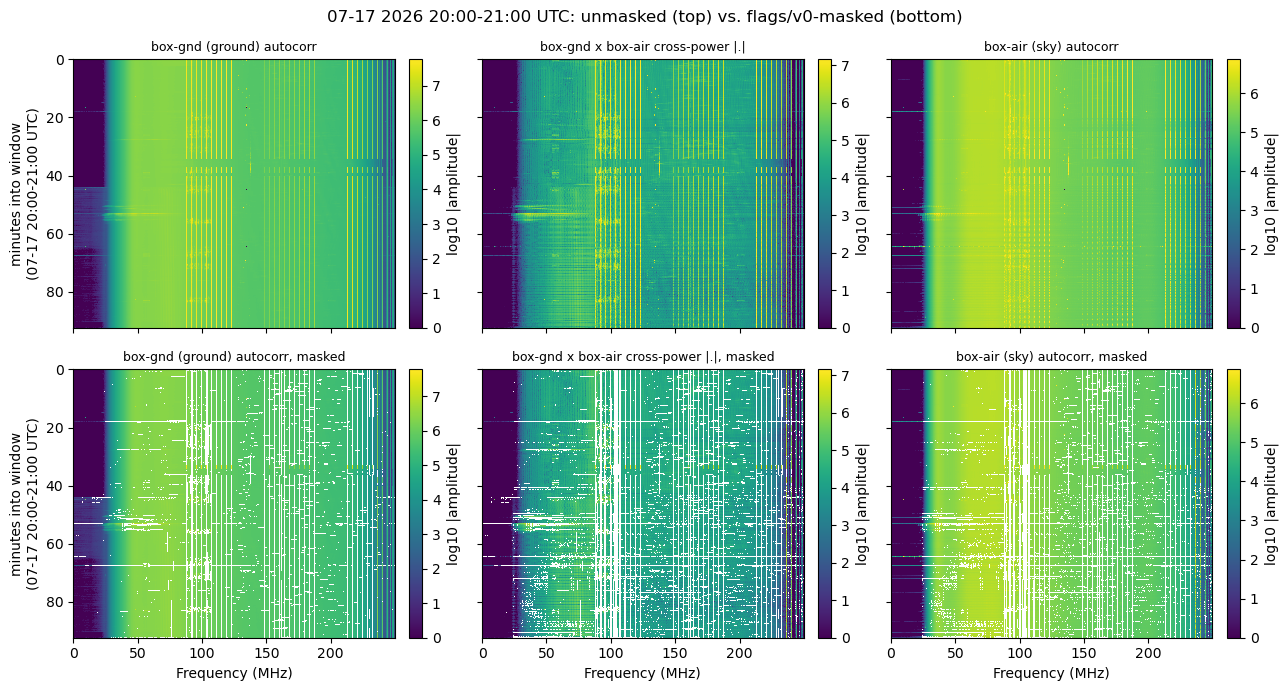

In [4]:

extent = [freqs.min(), freqs.max(), minutes.max(), minutes.min()]  # time increases downward

panels_before = [("box-gnd (ground) autocorr", log0),
                  ("box-gnd x box-air cross-power |.|", log04),
                  ("box-air (sky) autocorr", log4)]
panels_after = [("box-gnd (ground) autocorr, masked", log0_masked),
                 ("box-gnd x box-air cross-power |.|, masked", log04_masked),
                 ("box-air (sky) autocorr, masked", log4_masked)]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
# Color scale fixed per column from the UNMASKED array, and reused for
# the masked row -- otherwise each panel autoscales to its own
# remaining pixels and the before/after comparison is not honest.
col_ranges = [np.nanpercentile(arr, [2, 98]) for _, arr in panels_before]
for row, panels in enumerate((panels_before, panels_after)):
    for col, (title, arr) in enumerate(panels):
        ax = axes[row, col]
        vmin, vmax = col_ranges[col]
        im = ax.imshow(arr, aspect="auto", extent=extent,
                        vmin=vmin, vmax=vmax, cmap="viridis",
                        interpolation="nearest")
        ax.set_title(title, fontsize=9)
        if row == 1:
            ax.set_xlabel("Frequency (MHz)")
        if col == 0:
            ax.set_ylabel("minutes into window\n(07-17 20:00-21:00 UTC)")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                     label="log10 |amplitude|")
fig.suptitle("07-17 2026 20:00-21:00 UTC: unmasked (top) vs. flags/v0-masked (bottom)")
fig.tight_layout()
plt.show()



## Reading the panels

- **Top row (unmasked):** the box-air (sky) autocorrelation shows the
  1.953125 MHz digital self-comb as horizontal banding (constant in
  time, periodic in frequency) plus scattered transient streaks
  (airplane/meteor-scatter candidates). The cross-power panel inherits
  structure from both legs.
- **Bottom row (masked):** the comb banding and transient streaks are
  blanked on both autocorrelation panels and, correctly, on the cross
  panel wherever *either* leg was flagged -- the point of the union
  rule. What survives is the underlying smooth bandpass plus genuinely
  clean time/frequency cells.
- This is a **visual** check, not a new statistic: `flags/v0`'s own
  `summary.json` already reports the per-band, per-day kept fractions.
  What this notebook adds is confirmation that the *shape* of what gets
  blanked matches what the eye identifies as interference, on both
  inputs and on the product formed from both.

**Not resolved by this check:** whether cross-power specifically would
benefit from its own detector (built on `|cross|` or the cross phase)
rather than inheriting the autocorrelation masks -- out of scope here,
noted as a possible follow-on if useful.
